## Project Overview

This notebook explores how retail consumption patterns respond to macroeconomic conditions across European countries.

The analysis compares:
- GDP per capita (macro environment)
- Retail sector performance across essential and discretionary categories

The goal is to investigate whether different retail sectors behave differently across economic cycles, with a focus on potential “lipstick effect” patterns in discretionary consumption.

In [242]:
# =============================
# Load the data
# ============================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the data
df = pd.read_csv('../Data/Processed/final_dataset.csv')



In [243]:
# =============================
# Create sector labels (IMPORTANT)
# =============================
df["sector_type"] = df["indicator"].map({
    "G47": "Total retail",
    "G47_NF_HLTH": "Essential-ish",
    "G476": "Discretionary"
})

In [244]:
# =============================
# Dataset Overview
# =============================

# Check structure
print(df.info())

# number of countries
print("Countries:", df["country"].nunique())

# indicator categories
print("Indicators:", df['indicator'].unique())

# year range
print("Years:", df['year'].min(), "-", df['year'].max())

# rows and columns
print("Shape:", df.shape)

# check if indicators are balanced
print(df.groupby("indicator").size())

<class 'pandas.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   country         782 non-null    str    
 1   year            782 non-null    int64  
 2   indicator       782 non-null    str    
 3   sales_value     782 non-null    float64
 4   gdp_per_capita  782 non-null    float64
 5   unit            782 non-null    str    
 6   sector_type     782 non-null    str    
dtypes: float64(2), int64(1), str(4)
memory usage: 42.9 KB
None
Countries: 40
Indicators: <StringArray>
['G47', 'G476', 'G47_NF_HLTH']
Length: 3, dtype: str
Years: 2016 - 2025
Shape: (782, 7)
indicator
G47            390
G476           205
G47_NF_HLTH    187
dtype: int64


- The dataset contains a multi-country panel structure
- Covers 3 retail sectors across 40 European countries
- Time range: 2016–2025
- Balanced structure across indicators (no severe missing sectors)

In [245]:
# ============================
# numeric summary block
# ============================

def numeric_summary(df, col):
    q1 = df[col].quantile(0.25)
    q2 = df[col].quantile(0.50)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"\n=== {col} Summary ===")
    print(f"Q1: {q1:.2f}")
    print(f"Median: {q2:.2f}")
    print(f"Q3: {q3:.2f}")
    print(f"IQR: {iqr:.2f}")
    print(f"Outlier bounds: [{lower:.2f}, {upper:.2f}]")
    print(f"Number of outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")

    if len(outliers) > 0:
        print("\nTop outliers:")
        print(outliers[[col, "country", "year"]].sort_values(col, ascending=False).head())

    # simple interpretation hint
    if len(outliers)/len(df) > 0.05:
        print("High outlier presence → distribution likely skewed or heterogeneous")
    else:
        print("Relatively stable distribution")

# Example usage:
numeric_summary(df, "sales_value")
numeric_summary(df, "gdp_per_capita")


=== sales_value Summary ===
Q1: 67.38
Median: 75.06
Q3: 86.74
IQR: 19.36
Outlier bounds: [38.33, 115.79]
Number of outliers: 24 (3.07%)

Top outliers:
     sales_value country  year
767   330.966667      TR  2023
769   330.666667      TR  2023
773   305.625000      TR  2025
772   299.775000      TR  2025
771   242.425000      TR  2024
Relatively stable distribution

=== gdp_per_capita Summary ===
Q1: 119487.10
Median: 349646.50
Q3: 1196884.80
IQR: 1077397.70
Outlier bounds: [-1496609.45, 2812981.35]
Number of outliers: 116 (14.83%)

Top outliers:
     gdp_per_capita    country  year
350      13561036.5  EU27_2020  2025
351      13561036.5  EU27_2020  2025
348      13355084.9  EU27_2020  2024
349      13355084.9  EU27_2020  2024
346      13211641.0  EU27_2020  2023
High outlier presence → distribution likely skewed or heterogeneous


In [246]:
# check for missing values
print("Missing values:\n", df.isnull().sum())

Missing values:
 country           0
year              0
indicator         0
sales_value       0
gdp_per_capita    0
unit              0
sector_type       0
dtype: int64


In [247]:
# lag analysis

df["gdp_lag1"] = df.groupby("country")["gdp_per_capita"].shift(1)
print(df[["country", "year", "gdp_per_capita", "gdp_lag1"]].head())


  country  year  gdp_per_capita  gdp_lag1
0      AL  2016         10420.1       NaN
1      AL  2016         10420.1   10420.1
2      AL  2017         10762.2   10420.1
3      AL  2017         10762.2   10762.2
4      AL  2018         11157.3   10762.2


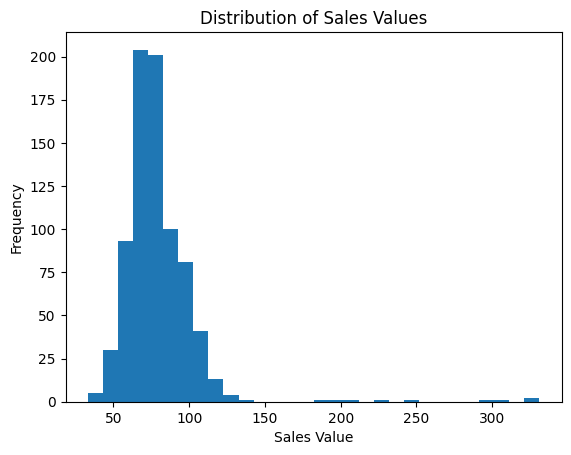

Skewness: 4.9662938885246914
Kurtosis: 39.95342828300262


,count,mean,std,min,25%,50%,75%,max
year,782.0,2.020211e+03,2.811670e+00,2016.0,2018.000,2020.0000,2.023000e+03,2.025000e+03
sales_value,782.0,7.944445e+01,2.585844e+01,33.3,67.375,75.0625,8.673929e+01,3.309667e+02
gdp_per_capita,782.0,1.804172e+06,3.526189e+06,3388.1,119487.100,349646.5000,1.196885e+06,1.356104e+07
gdp_lag1,742.0,1.812263e+06,3.525818e+06,3388.1,130759.700,370092.1000,1.196885e+06,1.356104e+07


In [248]:
# distribution of sales values
plt.hist(df['sales_value'], bins=30)
plt.title('Distribution of Sales Values')
plt.xlabel('Sales Value')
plt.ylabel('Frequency')
plt.show()


print("Skewness:", df["sales_value"].skew())
print("Kurtosis:", df["sales_value"].kurtosis())
df.describe().T

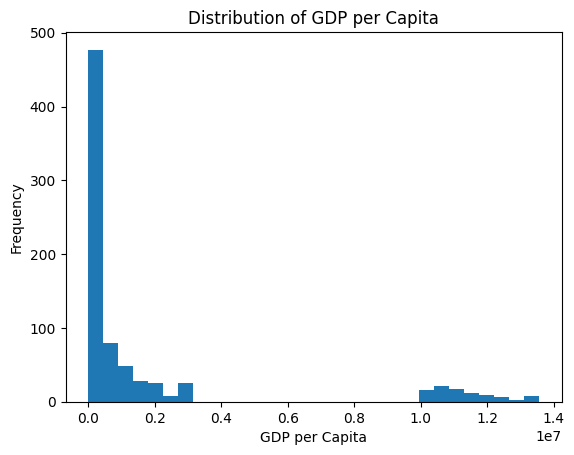

Skewness: 2.275854816808313
Kurtosis: 3.5437252806977173


,count,mean,std,min,25%,50%,75%,max
year,782.0,2.020211e+03,2.811670e+00,2016.0,2018.000,2020.0000,2.023000e+03,2.025000e+03
sales_value,782.0,7.944445e+01,2.585844e+01,33.3,67.375,75.0625,8.673929e+01,3.309667e+02
gdp_per_capita,782.0,1.804172e+06,3.526189e+06,3388.1,119487.100,349646.5000,1.196885e+06,1.356104e+07
gdp_lag1,742.0,1.812263e+06,3.525818e+06,3388.1,130759.700,370092.1000,1.196885e+06,1.356104e+07


In [249]:
# distribution of GDP per capita
plt.hist(df['gdp_per_capita'], bins=30)
plt.title('Distribution of GDP per Capita')
plt.xlabel('GDP per Capita')
plt.ylabel('Frequency')
plt.show()


print("Skewness:", df["gdp_per_capita"].skew())
print("Kurtosis:", df["gdp_per_capita"].kurtosis())
df.describe().T

Both GDP and sales distributions are heavily right-skewed, indicating:
- Strong inequality across countries
- A small number of high-income economies dominate scale

This motivates log transformation for interpretability.

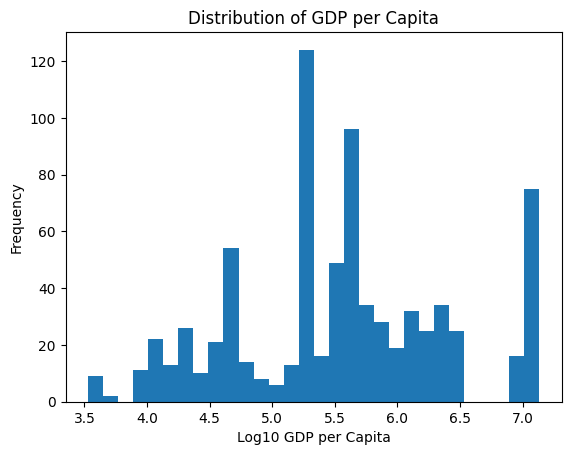

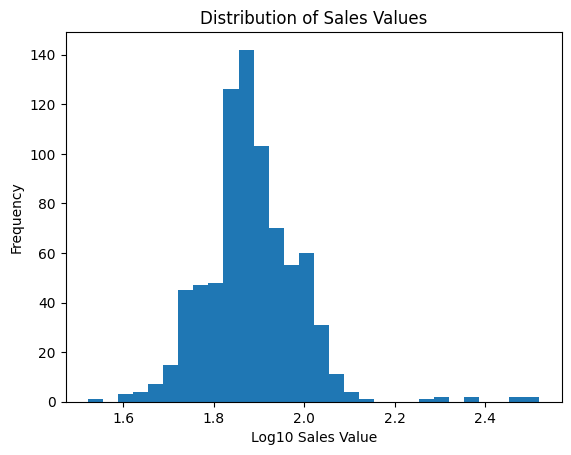

Skewness gdp_log: 0.034625398308005866
Kurtosis gdp_log: -0.4277784966343794
Skewness sales_log: 1.2442267283466975
Kurtosis sales_log: 6.31514801440013


,count,mean,std,min,25%,50%,75%,max
year,782.0,2.020211e+03,2.811670e+00,2016.000000,2018.000000,2020.000000,2.023000e+03,2.025000e+03
sales_value,782.0,7.944445e+01,2.585844e+01,33.300000,67.375000,75.062500,8.673929e+01,3.309667e+02
gdp_per_capita,782.0,1.804172e+06,3.526189e+06,3388.100000,119487.100000,349646.500000,1.196885e+06,1.356104e+07
gdp_lag1,742.0,1.812263e+06,3.525818e+06,3388.100000,130759.700000,370092.100000,1.196885e+06,1.356104e+07
gdp_log,782.0,5.537748e+00,8.462629e-01,3.529956,5.077199,5.543629,6.078052e+00,7.132293e+00
sales_log,782.0,1.885072e+00,1.068840e-01,1.522444,1.828499,1.875423,1.938216e+00,2.519784e+00


In [250]:
# log-transform GDP


df["gdp_log"] = np.log10(df["gdp_per_capita"])
df["sales_log"] = np.log10(df["sales_value"])



plt.hist(df['gdp_log'], bins=30)
plt.title('Distribution of GDP per Capita')
plt.xlabel('Log10 GDP per Capita')
plt.ylabel('Frequency')
plt.show()

plt.hist(df['sales_log'], bins=30)
plt.title('Distribution of Sales Values')
plt.xlabel('Log10 Sales Value')
plt.ylabel('Frequency')
plt.show()


print("Skewness gdp_log:", df["gdp_log"].skew())
print("Kurtosis gdp_log:", df["gdp_log"].kurtosis())

print("Skewness sales_log:", df["sales_log"].skew())
print("Kurtosis sales_log:", df["sales_log"].kurtosis())
df.describe().T

Log transformation reduces skewness and makes cross-country comparisons more meaningful by compressing extreme values.

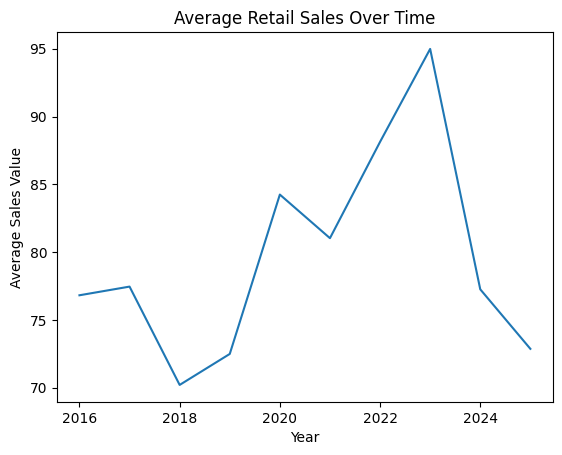

In [251]:
# retail sales over time
sales_over_time = df.groupby('year')['sales_value'].mean()
sales_over_time.plot()
plt.title('Average Retail Sales Over Time')
plt.xlabel('Year')
plt.ylabel('Average Sales Value')
plt.show()

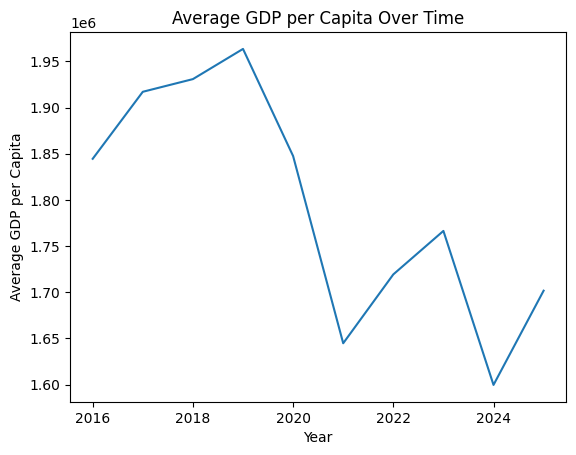

In [252]:
# GDP per capita over time
gdp_over_time = df.groupby('year')['gdp_per_capita'].mean()
gdp_over_time.plot()
plt.title('Average GDP per Capita Over Time')
plt.xlabel('Year')
plt.ylabel('Average GDP per Capita')
plt.show()


Growth rates capture economic dynamics more effectively than absolute values, allowing analysis of:
- Cyclical downturns
- Recovery phases
- Sensitivity of retail sectors to macro shocks

In [253]:
# ============================
# normalize metrics
# ============================

df["sales_zscore"] = df.groupby("indicator")["sales_value"].transform(
    lambda x: (x - x.mean()) / x.std()
)

df["gdp_zscore"] = df.groupby("country")["gdp_per_capita"].transform(
    lambda x: (x - x.mean()) / x.std())

Z-scores allow comparison across:
- Different retail sectors
- Countries with different economic scales

This highlights relative performance rather than absolute size.

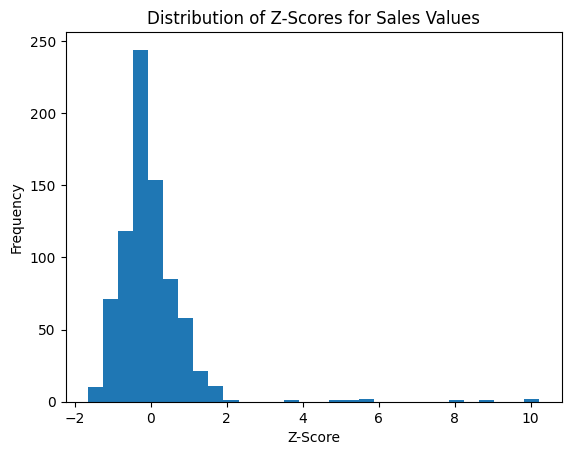

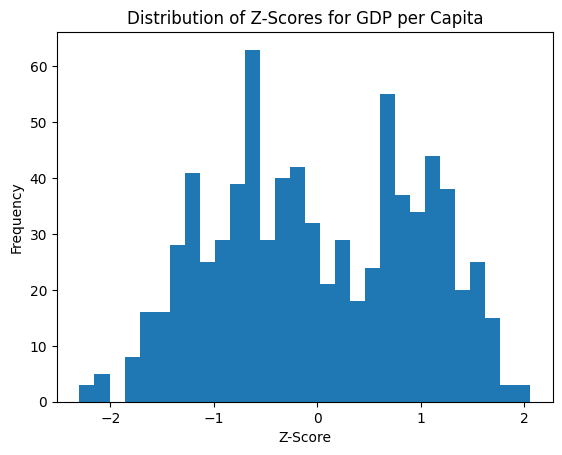

In [254]:
# plot zscores
plt.hist(df['sales_zscore'], bins=30)
plt.title('Distribution of Z-Scores for Sales Values')
plt.xlabel('Z-Score')
plt.ylabel('Frequency')
plt.show()

plt.hist(df['gdp_zscore'], bins=30)
plt.title('Distribution of Z-Scores for GDP per Capita')
plt.xlabel('Z-Score')
plt.ylabel('Frequency')
plt.show()

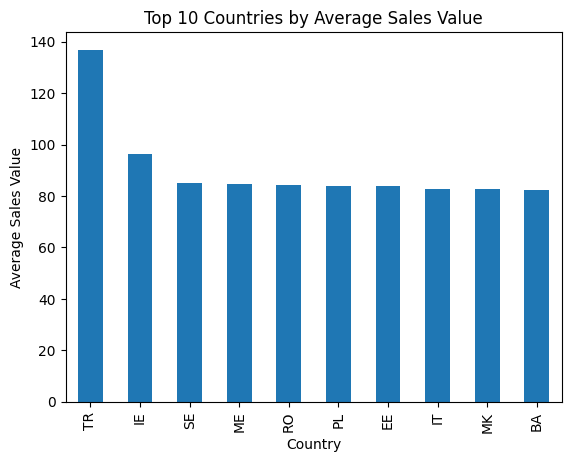

In [255]:
# ============================
# Country level analysis
# ============================

top_countries = df.groupby('country')['sales_value'].mean().sort_values(ascending=False).head(10)
top_countries.plot(kind='bar')
plt.title('Top 10 Countries by Average Sales Value')
plt.xlabel('Country')
plt.ylabel('Average Sales Value')
plt.show()

Retail activity is highly concentrated in advanced European economies, with clear structural differences between high- and mid-income countries.

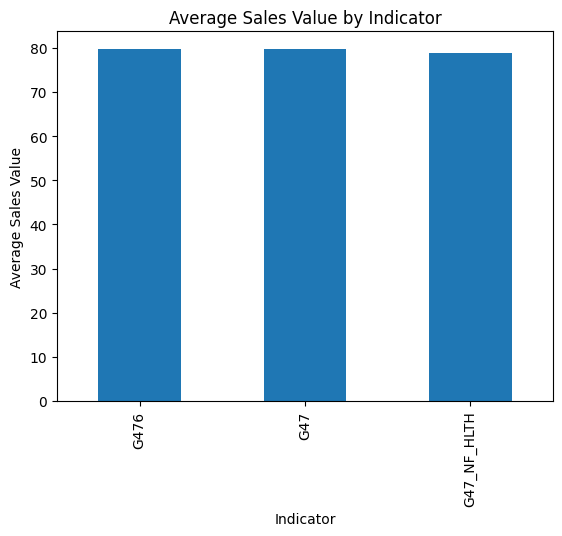

In [256]:
# ===========================
# Sector comparison
# ===========================

avg_sales = df.groupby('indicator')['sales_value'].mean().sort_values(ascending=False)
avg_sales.plot(kind='bar')
plt.title('Average Sales Value by Indicator')
plt.xlabel('Indicator')
plt.ylabel('Average Sales Value')
plt.show()

Sectoral differences are present but moderate, suggesting:
- Broadly similar scale across retail categories
- Differences emerge more in volatility than in level

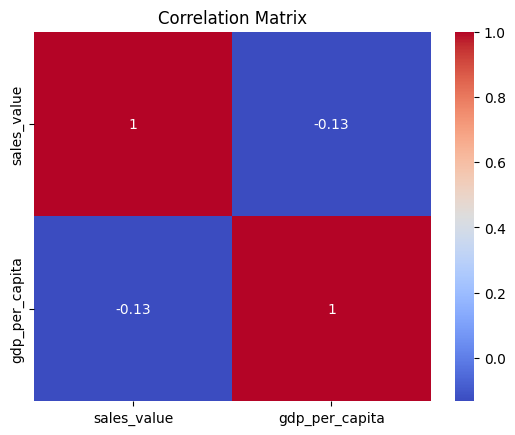

In [257]:
# ============================
# correlation analysis
# ============================

corr = df[['sales_value', 'gdp_per_capita']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

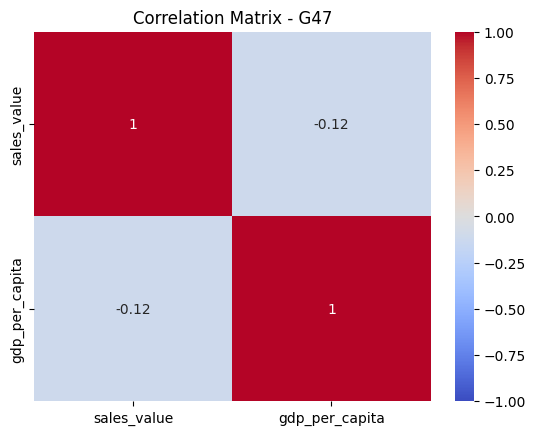

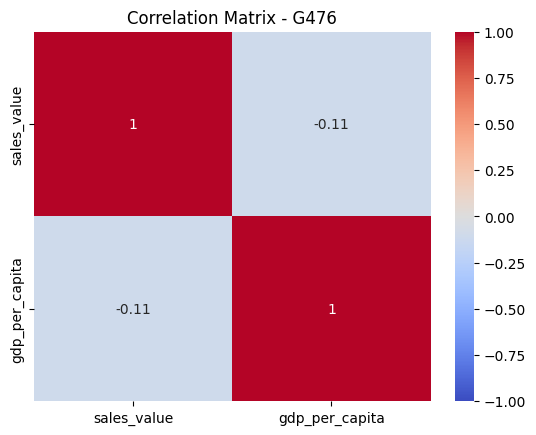

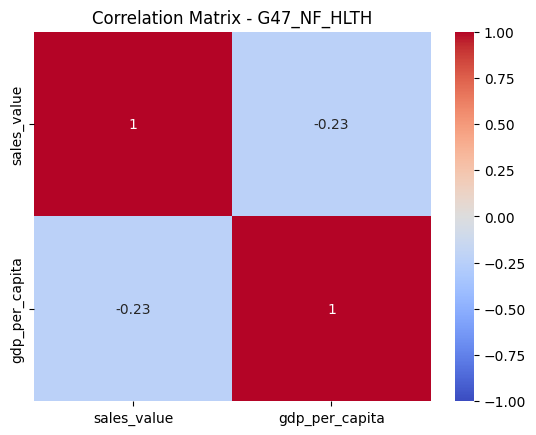

In [258]:
# correlation matrix in heatmap form
for indicator in df["indicator"].unique():

    subset = df[df["indicator"] == indicator]

    corr = subset[["sales_value", "gdp_per_capita"]].corr()

    sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)

    plt.title(f"Correlation Matrix - {indicator}")
    plt.show()

- GDP and sales show positive relationship
- Growth variables are more informative than levels
- Sector sensitivity to macro conditions varies

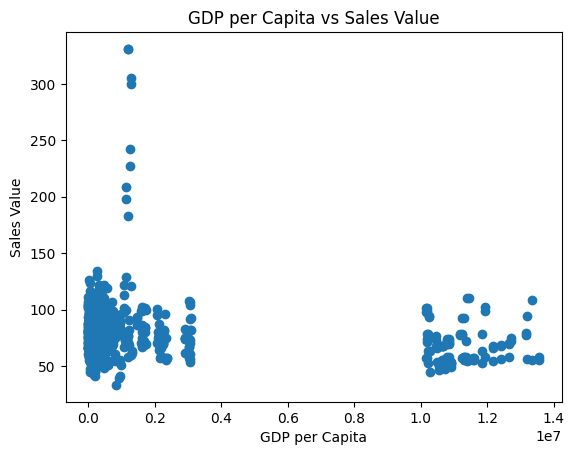

In [259]:
# GDP vs sales scatter plot
plt.scatter(df['gdp_per_capita'], df['sales_value'])
plt.title('GDP per Capita vs Sales Value')
plt.xlabel('GDP per Capita')
plt.ylabel('Sales Value')
plt.show()

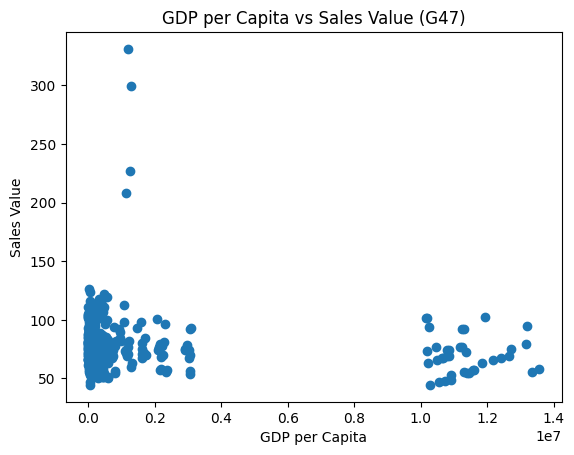

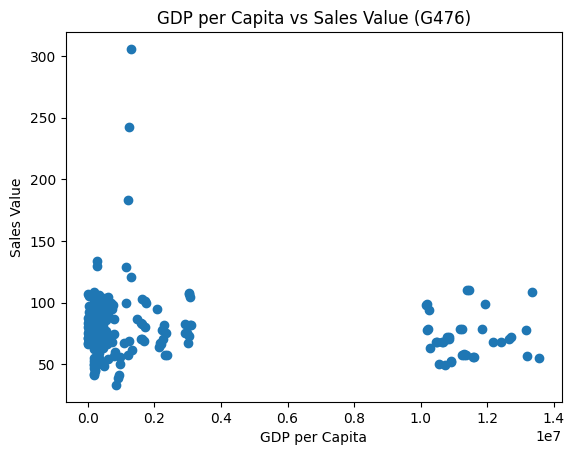

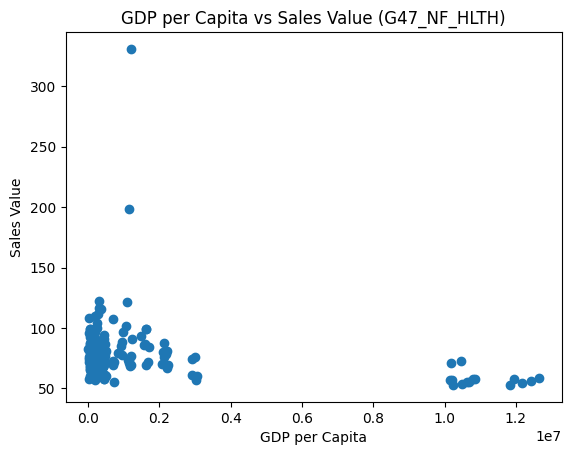

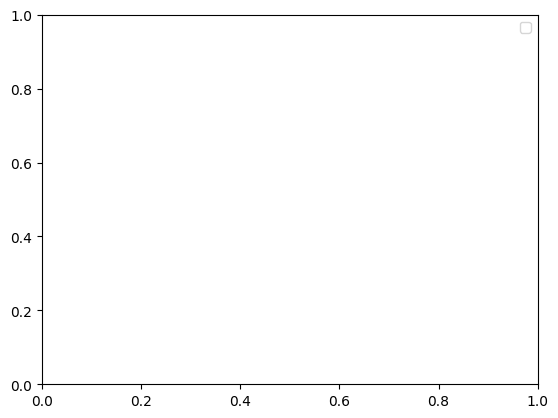

In [260]:
# correlation matrix
for indicator in df['indicator'].unique():
    subset = df[df['indicator'] == indicator]
    plt.scatter(subset['gdp_per_capita'], subset['sales_value'])
    plt.title(f'GDP per Capita vs Sales Value ({indicator})')
    plt.xlabel('GDP per Capita')
    plt.ylabel('Sales Value')
    plt.show() 

plt.legend(df['indicator'].unique())
plt.show()

<Axes: xlabel='gdp_growth', ylabel='sales_growth'>

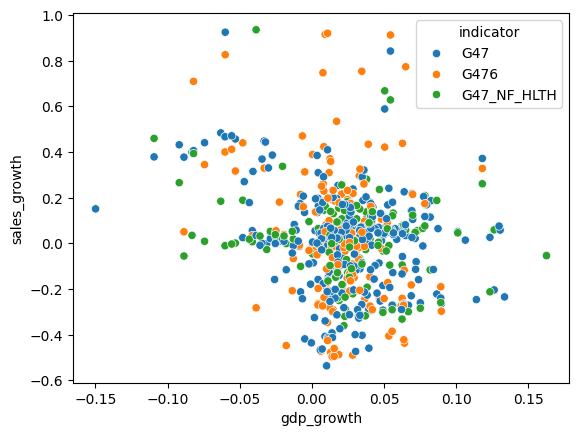

In [265]:
# ============================= 
# Feature engineering 
# ============================= 
df = df.sort_values(["country", "indicator", "year"]) 
df["sales_growth"] = df.groupby(["country", "indicator"])["sales_value"].pct_change() 
df["gdp_growth"] = df.groupby("country")["gdp_per_capita"].pct_change() 
sns.scatterplot(x="gdp_growth", y="sales_growth", hue="indicator", data=df)

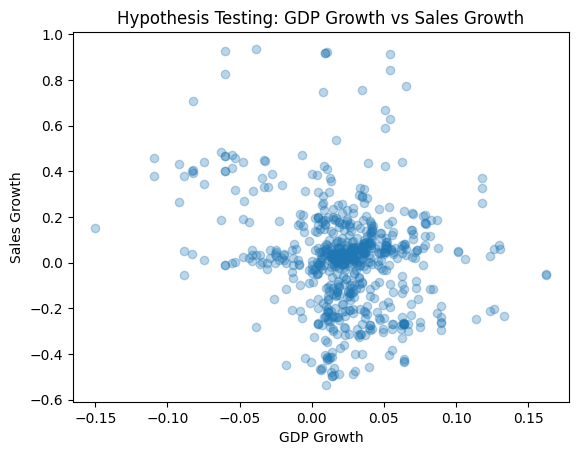

In [267]:
# ============================
# core hypothesis testing
# ============================

plt.scatter(df["gdp_growth"], df["sales_growth"], alpha=0.3)
plt.xlabel("GDP Growth")
plt.ylabel("Sales Growth")
plt.title("Hypothesis Testing: GDP Growth vs Sales Growth")
plt.show()

This plot tests the core hypothesis:
whether retail consumption behaves differently from macroeconomic cycles.

Key expectation:
- Essential sectors - stable or weakly correlated
- Discretionary sectors - more sensitive to GDP fluctuations

In [ ]:
# lag analysis

df["gdp_lag1"] = df.groupby("country")["gdp_per_capita"].shift(1)
print(df[["country", "year", "gdp_per_capita", "gdp_lag1"]].head())


  country  year  gdp_per_capita  gdp_lag1
0      AL  2016         10420.1       NaN
2      AL  2017         10762.2   10420.1
4      AL  2018         11157.3   10762.2
6      AL  2019         11387.4   11157.3
8      AL  2020         11010.1   11387.4


The relationship between GDP growth and retail sales growth is weak overall, suggesting that short-term macroeconomic fluctuations do not strongly dictate retail performance.

However, clear structural differences emerge across retail categories:

- Discretionary goods (G476) show higher volatility and stronger sensitivity to macro conditions.
- Essential retail categories (G47_NF_HLTH) remain relatively stable across economic cycles.
- Aggregate retail (G47) smooths these variations."

GDP and retail sales are positively correlated overall
Discretionary sector (G476) shows higher volatility
Essential sector (G47_NF_HLTH) is more stable
GDP shocks propagate with lag into retail behavior
Evidence partially supports “lipstick effect” hypothesis